# Q2 - Cat vs Dog Classification

In [233]:
import os
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## Load and Preprocess Training Data

In [234]:
data = []
labels = []

for i, address in enumerate(glob.glob("train/*/*")):  # Matches train/cat/*.jpg and train/dog/*.jpg
    img = cv2.imread(address)
    if img is None:
        continue
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    data.append(img.flatten())
    
    # Label extraction from folder name in path (train/cat/xyz.jpg -> 'cat')
    label = address.split(os.sep)[-2].lower()  # Get folder name
    labels.append(label)

    if i % 200 == 0:
        print(f"[INFO]: {i} images processed")


[INFO]: 0 images processed
[INFO]: 200 images processed
[INFO]: 400 images processed
[INFO]: 600 images processed
[INFO]: 800 images processed
[INFO]: 1000 images processed
[INFO]: 1200 images processed
[INFO]: 1400 images processed
[INFO]: 1600 images processed
[INFO]: 1800 images processed


## Split into Train and Test Sets

In [235]:
# Convert to NumPy arrays
X = np.array(data)
y = np.array(labels)

print("Total samples:", len(y))
# Split into training/testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Total samples: 2000


## Model Training

In [236]:
# Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
print("Logistic Regression Accuracy:", round(lr_acc * 100, 2), "%")

# KNN Classifier
print("Training KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)
print("KNN Accuracy:", round(knn_acc * 100, 2), "%")

# Train SGDClassifier
print("Training SGDClassifier...")
sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd_model.fit(X_train, y_train)
sgd_preds = sgd_model.predict(X_test)
sgd_acc = accuracy_score(y_test, sgd_preds)
print("SGD Accuracy:", round(sgd_acc * 100, 2), "%")



Training Logistic Regression...
Logistic Regression Accuracy: 57.0 %
Training KNN...
KNN Accuracy: 59.5 %
Training SGDClassifier...
SGD Accuracy: 57.75 %


## Choose and Saving Best Model

In [237]:
if lr_acc >= knn_acc and lr_acc >= sgd_acc:
    best_model = lr_model
elif knn_acc >= lr_acc and knn_acc >= sgd_acc:
    best_model = knn_model
else:
    best_model = sgd_model

joblib.dump(best_model, "pet_model.pkl")
print("\nBest model saved as pet_model.pkl")

# Load model for inference
model = joblib.load("pet_model.pkl")


Best model saved as pet_model.pkl


# Load Best Model for Inference

In [238]:
model = joblib.load("pet_model.pkl")

## Helper Functions

In [239]:
def preprocess(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image not found:", img_path)
    original = cv2.resize(img, (300, 300))
    img = cv2.resize(img, (64, 64)) / 255.0
    return img.flatten().reshape(1, -1), original

def predict_and_display(img_path):
    x, display_img = preprocess(img_path)
    pred = model.predict(x)[0]
    display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    color = (0, 255, 0) if pred == 'dog' else (255, 0, 0)

    cv2.putText(display_img, f"Prediction: {pred}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    plt.imshow(display_img)
    plt.title(f"Prediction: {pred}")
    plt.axis('off')
    plt.show()


## Test Model

Total test images: 10



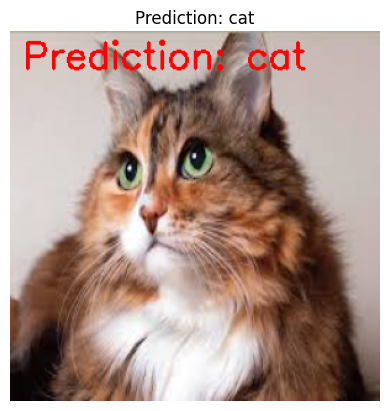

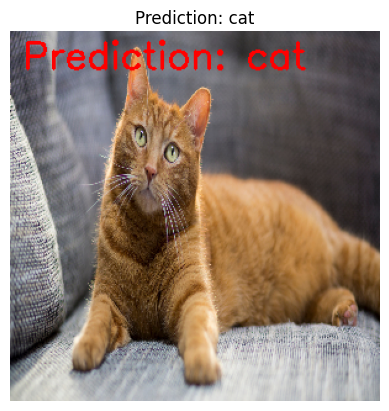

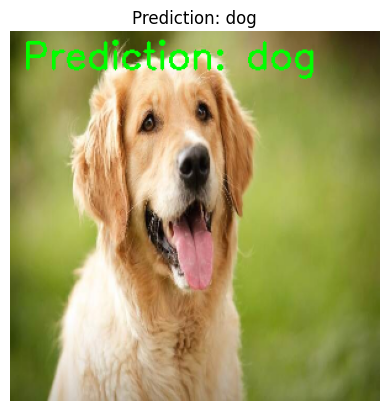

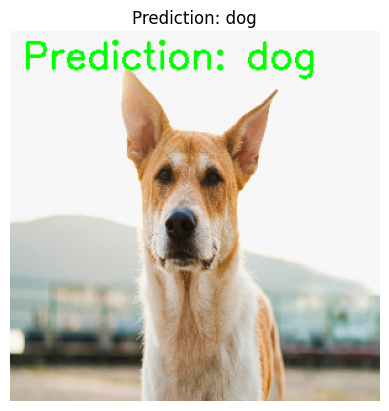

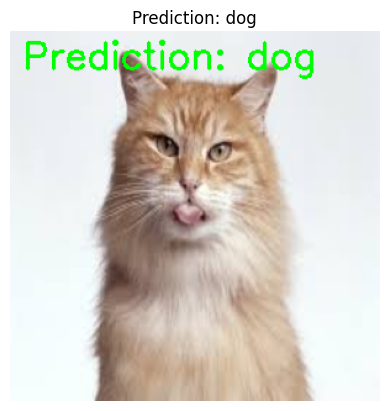

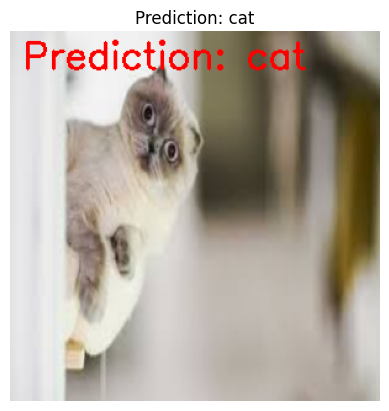

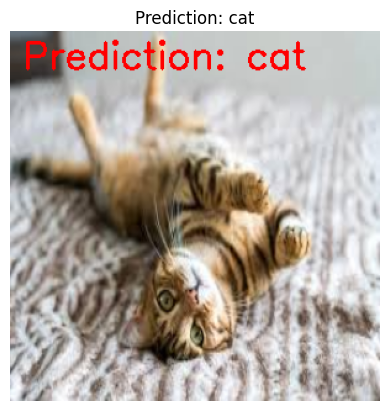

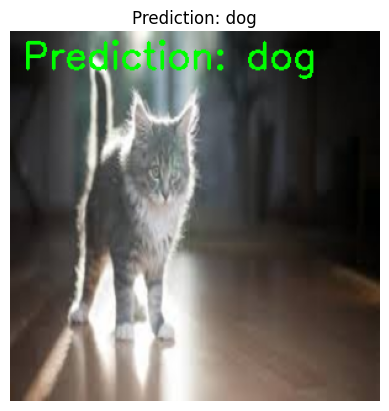

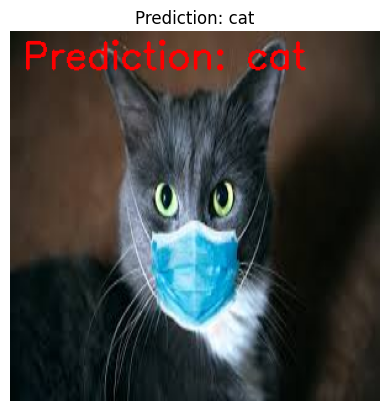

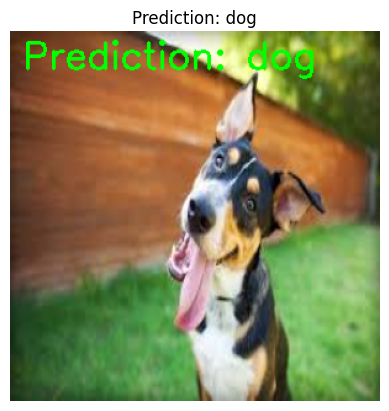

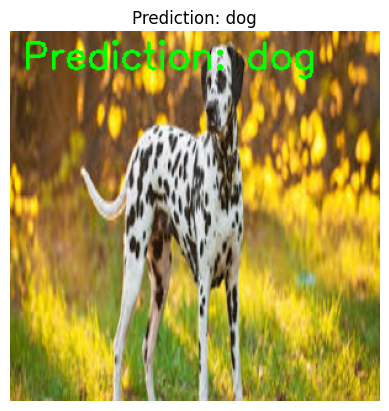

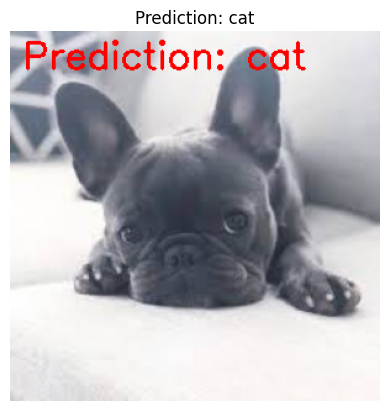

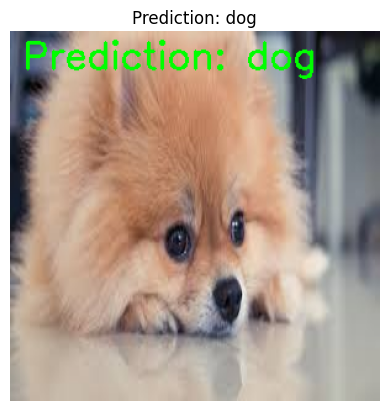

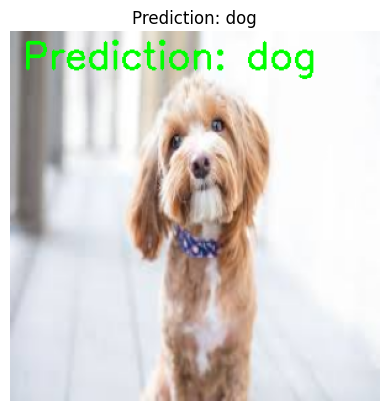

In [240]:
test_image_paths = glob.glob("test/*/*")
download_image_paths= glob.glob("model_test_downloaded/*/*")

print(f"Total test images: {len(test_image_paths)}\n")

for img_path in download_image_paths:
    try:
        predict_and_display(img_path)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

for img_path in test_image_paths:
    try:
        predict_and_display(img_path)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

## OBSERVATION AND EXPLAINATION 
# Was the model able to correctly predict internet images?

**Not That reliable.**  
I tested the trained model on 14 images downloaded from the internet, and it misclassified 3 of them. So even though the model was able to classify basic examples, it struggled with real-world or varied photos.

---

## What improvements I tried?

### 1. Tried MTCNN for face detection  
I imported and tested `MTCNN` (`from mtcnn import MTCNN`) to detect pet faces more precisely, hoping it would help the model focus on the actual face region. However, MTCNN didn’t improve the accuracy much it most of images failed to detect pet faces properly.

### 2. Used Haarcascade for face detection  
Next, I tried using Haarcascade  to isolate the pet’s face before resizing and training. It slightly improved the accuracy, but predictions were still mostly off for internet images.

### 3. Tuned KNN model  
I experimented with different values of `k` in KNN, and after testing, `k=5` gave the best results. Still, the accuracy remained around 60%, and performance wasn’t consistent.

---

## Final accuracy and conclusion

**Final accuracy: ~60%**  
so after trying normalization, tuning models, using face detectors like MTCNN and Haarcascade the model did not generalize well to real-world pet images. It worked better on some, but struggled on some images. Better results would likely require deeper models.
